In [1]:
# Ejecucion local: no se monta Google Drive.
from pathlib import Path
print(f"Directorio de trabajo: {Path.cwd()}")


Directorio de trabajo: e:\EAN\TESIS_MAESTRIA\Ciencia_de_datos\experimentos


In [2]:
# ============================================================
# 1. IMPORTAR LIBRERÍAS NECESARIAS
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# 2. CARGAR DATASET DESDE ARCHIVO XLSX
# ============================================================
# En Google Colab puedes subir el archivo manualmente o montarlo desde Drive.
# Aquí asumimos que el archivo está en la ruta actual de trabajo.

ruta_archivo = "df_consumo_bime_clima_v3.xlsx"   # <-- Cambia este nombre por el tuyo

# Leer archivo Excel
df = pd.read_excel(ruta_archivo)

# Mostrar primeras filas para verificar carga correcta
print("Dataset cargado correctamente.")
display(df.head())

# Mostrar dimensiones iniciales
print(f"\nDimensiones iniciales del dataset: {df.shape}")

# ============================================================
# 3. DEFINIR VARIABLE OBJETIVO (TARGET)
# ============================================================

target = "consumo_promedio"

# Verificar que exista en el dataset
if target not in df.columns:
    raise ValueError(f"La variable objetivo '{target}' no existe en el dataset.")

# ============================================================
# 4. VARIABLES A ELIMINAR SEGÚN ANÁLISIS DE INGENIERÍA
# ============================================================

columnas_eliminar = [

    # --------------------------------------------------------
    # Variables con posible DATA LEAKAGE
    # (Muy relacionadas o derivadas directamente del target)
    # --------------------------------------------------------
    "metros_cubicos",
    "facturas",
    "suscriptores_facturados",
    "suscriptores_con_medidor",

    # --------------------------------------------------------
    # Variables categóricas / geográficas inicialmente removidas
    # --------------------------------------------------------
    "localidad",
    "latitud",
    "longitud",

    # --------------------------------------------------------
    # Variables climáticas redundantes / derivadas
    # --------------------------------------------------------
    "T2MWET",
    "T2MDEW",
    "T2M_RANGE",

    # --------------------------------------------------------
    # Variables de viento redundantes
    # --------------------------------------------------------
    "WS10M_MAX",
    "WS10M_MIN",
    "WS10M_RANGE",
    "WS2M_MAX",
    "WS2M_MIN",
    "WS2M_RANGE",

    # --------------------------------------------------------
    # Variables angulares inicialmente removidas
    # (Dirección del viento requiere transformación trigonométrica)
    # --------------------------------------------------------
    "WD10M",
    "WD2M",

    # --------------------------------------------------------
    # Variables radiativas redundantes
    # --------------------------------------------------------
    "ALLSKY_SFC_PAR_TOT",
    "CLRSKY_SFC_PAR_TOT",
    "ALLSKY_SFC_SW_DIFF",
    "ALLSKY_SFC_SW_DNI",
    "ALLSKY_SFC_UVA",
    "ALLSKY_SFC_UVB",
    "ALLSKY_SFC_UV_INDEX",
    "CLRSKY_SFC_SW_DWN",
    "TOA_SW_DWN"
]

# ============================================================
# 5. ELIMINAR SOLO COLUMNAS EXISTENTES (ROBUSTEZ)
# ============================================================
# Esto evita errores si alguna columna no está en el archivo.

columnas_existentes_eliminar = [
    col for col in columnas_eliminar if col in df.columns
]

df = df.drop(columns=columnas_existentes_eliminar)

# Mostrar columnas eliminadas
print("\nColumnas eliminadas:")
for col in columnas_existentes_eliminar:
    print(f" - {col}")

# ============================================================
# 6. SEPARAR FEATURES (X) Y TARGET (y)
# ============================================================

X = df.drop(columns=[target])
y = df[target]

# ============================================================
# 7. MOSTRAR RESUMEN FINAL
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO COMPLETADO")
print("==============================")

print(f"\nNúmero final de features: {X.shape[1]}")
print(f"Número de muestras: {X.shape[0]}")

print("\nFeatures finales utilizadas:")
for col in X.columns:
    print(f" - {col}")

# ============================================================
# 8. VISTA PRELIMINAR DEL DATASET LIMPIO
# ============================================================

display(X.head())

print("\nTarget preview:")
display(y.head())

Dataset cargado correctamente.


,año,localidad,BIMESTRE,metros_cubicos,facturas,consumo_promedio,suscriptores_facturados,suscriptores_con_medidor,latitud,longitud,...,WD10M,WD2M,WS10M,WS10M_MAX,WS10M_MIN,WS10M_RANGE,WS2M,WS2M_MAX,WS2M_MIN,WS2M_RANGE
0,2020,USAQUEN,1,4653292,213354,10.905097,212731.0,215097,4.73197,-74.05163,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
1,2020,CHAPINERO,1,2281601,93362,12.219109,93016.0,93684,4.67040,-74.04338,...,89.65,94.8,2.310,6.405,0.140,3.07,1.395,4.175,0.065,2.085
2,2020,SANTA FE,1,843631,33789,12.483811,33524.0,34703,4.60947,-74.08135,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
3,2020,SAN CRISTOBAL,1,1771678,80676,10.980205,80311.0,81072,4.58843,-74.07080,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945
4,2020,USME,1,1570282,78240,10.035033,77876.0,79159,4.53286,-74.11451,...,78.20,78.8,2.275,6.650,0.205,2.31,1.430,4.735,0.150,1.945



Dimensiones iniciales del dataset: (596, 49)

Columnas eliminadas:
 - metros_cubicos
 - facturas
 - suscriptores_facturados
 - suscriptores_con_medidor
 - localidad
 - latitud
 - longitud
 - T2MWET
 - T2MDEW
 - T2M_RANGE
 - WS10M_MAX
 - WS10M_MIN
 - WS10M_RANGE
 - WS2M_MAX
 - WS2M_MIN
 - WS2M_RANGE
 - WD10M
 - WD2M
 - ALLSKY_SFC_PAR_TOT
 - CLRSKY_SFC_PAR_TOT
 - ALLSKY_SFC_SW_DIFF
 - ALLSKY_SFC_SW_DNI
 - ALLSKY_SFC_UVA
 - ALLSKY_SFC_UVB
 - ALLSKY_SFC_UV_INDEX
 - CLRSKY_SFC_SW_DWN
 - TOA_SW_DWN

PREPROCESAMIENTO COMPLETADO

Número final de features: 21
Número de muestras: 596

Features finales utilizadas:
 - año
 - BIMESTRE
 - ALLSKY_SFC_LW_DWN
 - ALLSKY_SFC_SW_DWN
 - ALLSKY_SRF_ALB
 - CLOUD_AMT
 - GWETPROF
 - GWETROOT
 - GWETTOP
 - ONI
 - PRECTOTCORR
 - PRECTOTCORR_SUM
 - PS
 - QV2M
 - RH2M
 - T2M
 - T2M_MAX
 - T2M_MIN
 - TS
 - WS10M
 - WS2M


,año,BIMESTRE,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_SW_DWN,ALLSKY_SRF_ALB,CLOUD_AMT,GWETPROF,GWETROOT,GWETTOP,ONI,...,PRECTOTCORR_SUM,PS,QV2M,RH2M,T2M,T2M_MAX,T2M_MIN,TS,WS10M,WS2M
0,2020,1,31.615,19.135,0.15,62.185,0.775,0.765,0.760,0.49,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
1,2020,1,31.615,19.135,0.15,62.185,0.775,0.765,0.760,0.49,...,59.16,79.585,11.865,83.595,16.04,22.470,8.820,16.32,2.310,1.395
2,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
3,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430
4,2020,1,31.615,19.135,0.15,62.185,0.705,0.640,0.655,0.49,...,77.95,82.335,12.860,78.225,19.06,27.045,9.945,19.24,2.275,1.430



Target preview:


0    10.905097
1    12.219109
2    12.483811
3    10.980205
4    10.035033
Name: consumo_promedio, dtype: float64

Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos
La columna 'año' fue convertida a formato numérico.
Se aplicó transformación log1p al target 'consumo_promedio'.

Después de quitar targets nulos:
X_model: (596, 22)
y_model: (596,)

División de datos:
Train: (417, 22), (417,)
Val:   (89, 22), (89,)
Test:  (90, 22), (90,)

PREPROCESAMIENTO PARA PYTORCH COMPLETADO

Número final de features usadas por el modelo: 22
Batch size: 32

Nombres finales de las features:
1. año
2. ALLSKY_SFC_LW_DWN
3. ALLSKY_SFC_SW_DWN
4. ALLSKY_SRF_ALB
5. CLOUD_AMT
6. GWETPROF
7. GWETROOT
8. GWETTOP
9. ONI
10. PRECTOTCORR
11. PRECTOTCORR_SUM
12. PS
13. QV2M
14. RH2M
15. T2M
16. T2M_MAX
17. T2M_MIN
18. TS
19. WS10M
20. WS2M
21. BIMESTRE_sin
22. BIMESTRE_cos

Tamaños de tensores:
X_train_tensor: torch.Size([417, 22])
y_train_tensor: torch.Size([417, 1])
X_val_tensor:   torch.Size([89, 22])
y_val_tensor:   torch.Size([89, 1])
X_test_tensor:  torch.Size([90, 22])
y_test_tensor:  torch.Size([


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


[0]	validation_0-rmse:0.17807	validation_1-rmse:0.25611
[1]	validation_0-rmse:0.17616	validation_1-rmse:0.25504
[2]	validation_0-rmse:0.17433	validation_1-rmse:0.25273
[3]	validation_0-rmse:0.17291	validation_1-rmse:0.25371
[4]	validation_0-rmse:0.17171	validation_1-rmse:0.25355
[5]	validation_0-rmse:0.17015	validation_1-rmse:0.25373
[6]	validation_0-rmse:0.16871	validation_1-rmse:0.25311
[7]	validation_0-rmse:0.16753	validation_1-rmse:0.25350
[8]	validation_0-rmse:0.16642	validation_1-rmse:0.25383
[9]	validation_0-rmse:0.16485	validation_1-rmse:0.25170
[10]	validation_0-rmse:0.16379	validation_1-rmse:0.25197
[11]	validation_0-rmse:0.16308	validation_1-rmse:0.25186
[12]	validation_0-rmse:0.16182	validation_1-rmse:0.25202
[13]	validation_0-rmse:0.16113	validation_1-rmse:0.25171
[14]	validation_0-rmse:0.15995	validation_1-rmse:0.25248
[15]	validation_0-rmse:0.15884	validation_1-rmse:0.25220
[16]	validation_0-rmse:0.15847	validation_1-rmse:0.25275
[17]	validation_0-rmse:0.15739	validation

,Valor_real,Prediccion,Error_absoluto
0,11.404461,11.257005,0.147457
1,11.192153,11.471813,0.279660
2,10.600932,11.897288,1.296356
3,15.794589,10.995355,4.799234
4,11.060142,11.774226,0.714084
5,16.104217,10.600981,5.503236
6,10.845302,11.257005,0.411703
7,14.570527,12.315141,2.255386
8,10.067235,9.790956,0.276279
9,12.082005,10.348651,1.733354



Top 20 variables más importantes según XGBoost:


,feature,importance
19,WS2M,0.093176
11,PS,0.085589
15,T2M_MAX,0.079614
14,T2M,0.076956
20,BIMESTRE_sin,0.073989
8,ONI,0.054995
13,RH2M,0.050456
16,T2M_MIN,0.047516
9,PRECTOTCORR,0.044946
5,GWETPROF,0.041645


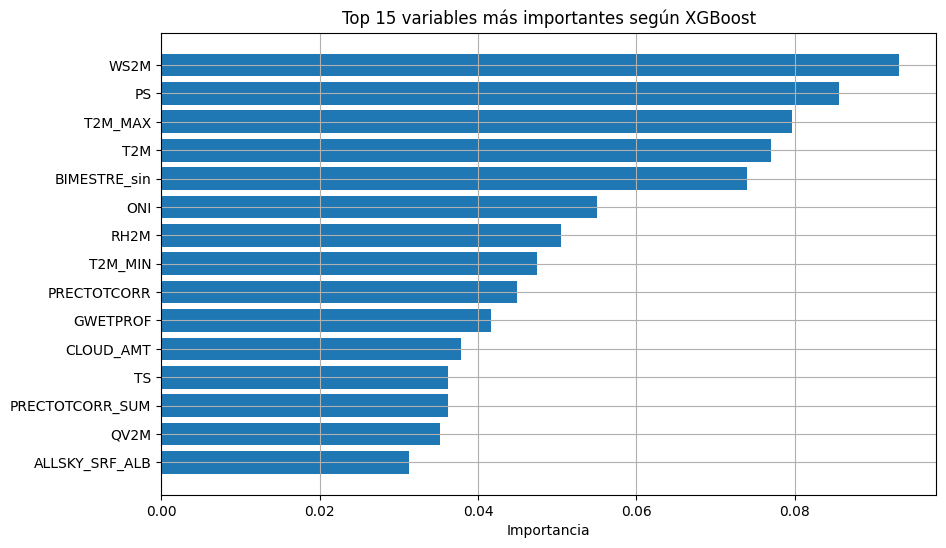

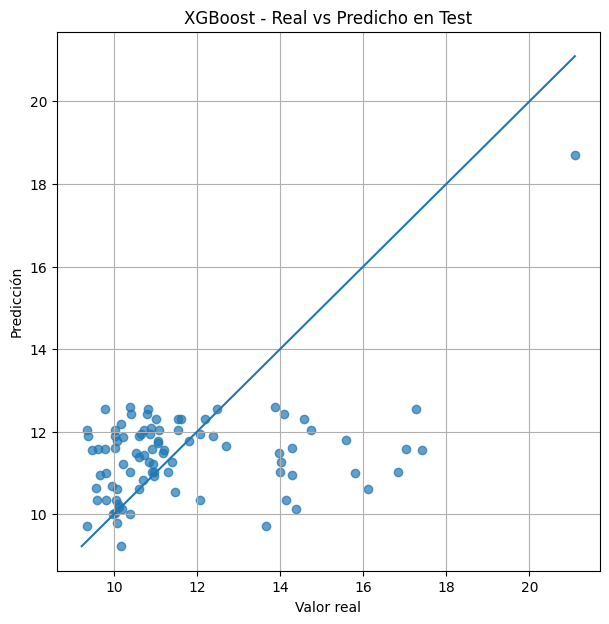

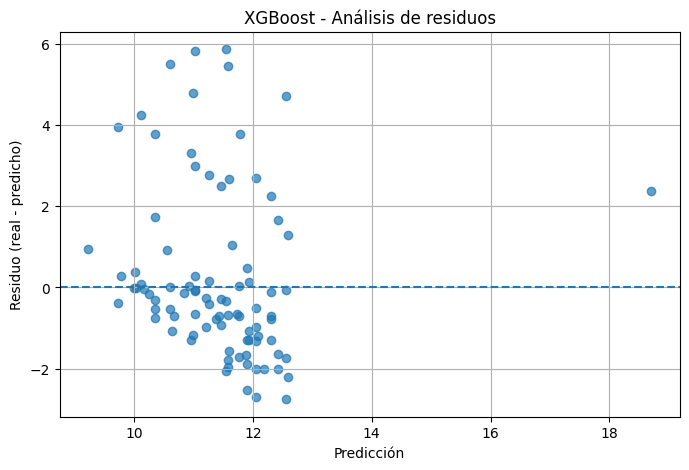


20 peores predicciones de XGBoost:


,Valor_real,Prediccion,Error_absoluto
33,17.420833,11.547341,5.873491
89,16.849002,11.024834,5.824168
5,16.104217,10.600981,5.503236
43,17.041598,11.580342,5.461255
3,15.794589,10.995355,4.799234
88,17.271118,12.551924,4.719194
35,14.376812,10.124086,4.252726
47,13.672494,9.725961,3.946533
37,15.583333,11.788668,3.794666
44,14.139062,10.348651,3.790411



RESUMEN FINAL XGBOOST
Test MAE  : 1.5170
Test RMSE : 2.0985
Test R²   : 0.1337


In [3]:
# ============================================================
# 9. IMPORTAR LIBRERÍAS PARA PREPROCESAMIENTO Y PYTORCH
# ============================================================

import math
import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ============================================================
# 10. HACER UNA COPIA DE SEGURIDAD DE X Y y
# ============================================================
# Esto evita modificar accidentalmente los datos originales.

X_model = X.copy()
y_model = y.copy()

# ============================================================
# 11. TRANSFORMAR BIMESTRE A REPRESENTACIÓN CÍCLICA
# ============================================================
# BIMESTRE toma valores periódicos: 1, 2, 3, 4, 5, 6
# El problema de dejarlo como entero es que:
# - 1 y 6 parecen lejanos numéricamente
# - pero realmente son cercanos en el ciclo anual
#
# Por eso usamos:
#   sin(2*pi*bimestre/6)
#   cos(2*pi*bimestre/6)

if "BIMESTRE" in X_model.columns:
    # Convertir BIMESTRE a numérico por seguridad
    X_model["BIMESTRE"] = pd.to_numeric(X_model["BIMESTRE"], errors="coerce")

    # Crear representación cíclica
    X_model["BIMESTRE_sin"] = np.sin(2 * np.pi * X_model["BIMESTRE"] / 6)
    X_model["BIMESTRE_cos"] = np.cos(2 * np.pi * X_model["BIMESTRE"] / 6)

    # Eliminar la columna original porque ya quedó representada mejor
    X_model = X_model.drop(columns=["BIMESTRE"])

    print("Se transformó 'BIMESTRE' a variables cíclicas: BIMESTRE_sin y BIMESTRE_cos")
else:
    print("La columna 'BIMESTRE' no está presente en X_model")

# ============================================================
# 12. ASEGURAR QUE 'año' SEA NUMÉRICO
# ============================================================
# En muchos archivos Excel algunas columnas llegan como texto.
# Aquí obligamos a que 'año' sea numérico si existe.

if "año" in X_model.columns:
    X_model["año"] = pd.to_numeric(X_model["año"], errors="coerce")
    print("La columna 'año' fue convertida a formato numérico.")
else:
    print("La columna 'año' no está presente en X_model")

# ============================================================
# 13. ASEGURAR QUE TODAS LAS FEATURES SEAN NUMÉRICAS
# ============================================================
# Como vas a entrenar una red neuronal tabular en PyTorch,
# todas las entradas deben ser numéricas.

for col in X_model.columns:
    X_model[col] = pd.to_numeric(X_model[col], errors="coerce")

# También forzamos el target a numérico
y_model = pd.to_numeric(y_model, errors="coerce")

# ============================================================
# 13.1 TRANSFORMAR EL TARGET CON log1p
# ============================================================
# Dado que consumo_promedio tiene una distribución muy sesgada
# y presenta valores extremos muy grandes, usamos log1p:
#
#   log1p(y) = log(1 + y)
#
# Esto comprime la cola larga del target y ayuda a que el modelo
# aprenda mejor la estructura general del problema.
#
# IMPORTANTE:
# Esto solo funciona si y >= 0, lo cual en este problema tiene sentido.
# Si hubiera valores negativos, habría que revisar antes.

if (y_model < 0).any():
    raise ValueError("La transformación log1p no puede aplicarse porque existen valores negativos en el target.")

y_model = np.log1p(y_model)

print("Se aplicó transformación log1p al target 'consumo_promedio'.")

# ============================================================
# 14. ELIMINAR FILAS DONDE EL TARGET SEA NULO
# ============================================================
# No se puede entrenar si la variable objetivo está vacía.

mask_target_valido = y_model.notna()

X_model = X_model.loc[mask_target_valido].reset_index(drop=True)
y_model = y_model.loc[mask_target_valido].reset_index(drop=True)

print(f"\nDespués de quitar targets nulos:")
print(f"X_model: {X_model.shape}")
print(f"y_model: {y_model.shape}")

# ============================================================
# 15. DIVIDIR EN TRAIN, VALIDATION Y TEST
# ============================================================
# Buena práctica:
# - train: para entrenar
# - validation: para ajustar hiperparámetros / early stopping
# - test: para evaluar el resultado final
#
# Aquí usamos:
# - 70% train
# - 15% validation
# - 15% test

X_train, X_temp, y_train, y_temp = train_test_split(
    X_model,
    y_model,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("\nDivisión de datos:")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

# ============================================================
# 16. IMPUTAR VALORES FALTANTES EN FEATURES
# ============================================================
# Muy importante:
# El imputador debe ajustarse SOLO con train
# y luego aplicarse a val/test.
#
# Aquí usamos la mediana porque suele ser robusta
# ante valores extremos en variables climáticas.

imputer_X = SimpleImputer(strategy="median")

X_train_imputed = imputer_X.fit_transform(X_train)
X_val_imputed   = imputer_X.transform(X_val)
X_test_imputed  = imputer_X.transform(X_test)

# ============================================================
# 17. ESCALAR FEATURES
# ============================================================
# Las redes neuronales suelen entrenar mejor cuando las variables
# tienen escalas comparables.
#
# Ajustamos el scaler SOLO con train y aplicamos a val/test.

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_imputed)
X_val_scaled   = scaler_X.transform(X_val_imputed)
X_test_scaled  = scaler_X.transform(X_test_imputed)

# ============================================================
# 18. ESCALAR EL TARGET (OPCIONAL PERO RECOMENDADO)
# ============================================================
# En regresión con deep learning, muchas veces ayuda escalar la salida.
# Esto estabiliza el entrenamiento si el target tiene magnitud grande.
#
# Luego, al evaluar, puedes revertir la escala.

scaler_y = StandardScaler()

y_train_reshaped = y_train.values.reshape(-1, 1)
y_val_reshaped   = y_val.values.reshape(-1, 1)
y_test_reshaped  = y_test.values.reshape(-1, 1)

y_train_scaled = scaler_y.fit_transform(y_train_reshaped)
y_val_scaled   = scaler_y.transform(y_val_reshaped)
y_test_scaled  = scaler_y.transform(y_test_reshaped)

# ============================================================
# 19. CONVERTIR A TENSORES DE PYTORCH
# ============================================================
# PyTorch trabaja con tensores. Para regresión usamos float32.

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_scaled, dtype=torch.float32)

# ============================================================
# 20. CREAR TensorDataset
# ============================================================
# Esto empaqueta features y target juntos.

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# ============================================================
# 21. CREAR DataLoaders
# ============================================================
# batch_size = cuántas muestras ve el modelo por iteración
# shuffle=True solo en train para mezclar ejemplos

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ============================================================
# 22. MOSTRAR RESUMEN FINAL DEL PREPROCESAMIENTO
# ============================================================

print("\n==============================")
print("PREPROCESAMIENTO PARA PYTORCH COMPLETADO")
print("==============================")

print(f"\nNúmero final de features usadas por el modelo: {X_train_tensor.shape[1]}")
print(f"Batch size: {batch_size}")

print("\nNombres finales de las features:")
columnas_finales = X_model.columns.tolist()
for i, col in enumerate(columnas_finales, start=1):
    print(f"{i}. {col}")

print("\nTamaños de tensores:")
print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"X_val_tensor:   {X_val_tensor.shape}")
print(f"y_val_tensor:   {y_val_tensor.shape}")
print(f"X_test_tensor:  {X_test_tensor.shape}")
print(f"y_test_tensor:  {y_test_tensor.shape}")

# ============================================================
# XGBOOST PARA REGRESIÓN TABULAR
# ============================================================
# Este bloque usa exactamente el mismo split de train/val/test
# que ya construiste para PyTorch, de modo que la comparación
# entre modelos sea justa.
#
# REQUISITO:
# Deben existir previamente estas variables:
#   X_train_scaled, X_val_scaled, X_test_scaled
#   y_train, y_val, y_test
#
# IMPORTANTE:
# Este bloque asume que y_train, y_val y y_test están en escala log1p,
# tal como vienes trabajando en tu pipeline actual.
# Al final revertimos a escala original con np.expm1().
# ============================================================

# Si XGBoost no está instalado en Colab, se instala.
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. DEFINIR EL MODELO XGBOOST
# ============================================================
# Estos hiperparámetros son una primera configuración razonable
# para regresión tabular. Luego podrás afinarlos si ves mejora.

xgb_model = XGBRegressor(
    n_estimators=300,          # Número máximo de árboles
    learning_rate=0.05,        # Tasa de aprendizaje
    max_depth=4,               # Profundidad máxima de cada árbol
    min_child_weight=3,        # Controla complejidad mínima de nodos
    subsample=0.8,             # Fracción de filas usadas por árbol
    colsample_bytree=0.8,      # Fracción de columnas usadas por árbol
    reg_alpha=0.0,             # Regularización L1
    reg_lambda=1.0,            # Regularización L2
    objective="reg:squarederror",  # Regresión estándar
    random_state=42,
    n_jobs=-1
)

# ============================================================
# 2. ENTRENAR EL MODELO
# ============================================================
# Usamos train y validation para early stopping.
# XGBoost detendrá el entrenamiento si deja de mejorar
# sobre el conjunto de validación.

xgb_model.fit(
    X_train_scaled,
    y_train.values,
    eval_set=[(X_train_scaled, y_train.values), (X_val_scaled, y_val.values)],
    verbose=True
)

# ============================================================
# 3. OBTENER PREDICCIONES
# ============================================================
# Como el target se entrenó en escala log1p,
# las predicciones salen también en esa escala.

y_pred_train_log = xgb_model.predict(X_train_scaled)
y_pred_val_log   = xgb_model.predict(X_val_scaled)
y_pred_test_log  = xgb_model.predict(X_test_scaled)

# ============================================================
# 4. DEVOLVER A ESCALA ORIGINAL
# ============================================================
# Como el target fue transformado con log1p,
# ahora revertimos con expm1.

y_train_real = np.expm1(y_train.values)
y_val_real   = np.expm1(y_val.values)
y_test_real  = np.expm1(y_test.values)

y_pred_train_real = np.expm1(y_pred_train_log)
y_pred_val_real   = np.expm1(y_pred_val_log)
y_pred_test_real  = np.expm1(y_pred_test_log)

# ============================================================
# 5. CALCULAR MÉTRICAS
# ============================================================

def calcular_metricas_regresion(y_true, y_pred, nombre_conjunto="Conjunto"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n==============================")
    print(f"RESULTADOS EN {nombre_conjunto.upper()}")
    print(f"==============================")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return mae, rmse, r2

mae_train_xgb, rmse_train_xgb, r2_train_xgb = calcular_metricas_regresion(
    y_train_real, y_pred_train_real, "Train"
)

mae_val_xgb, rmse_val_xgb, r2_val_xgb = calcular_metricas_regresion(
    y_val_real, y_pred_val_real, "Validation"
)

mae_test_xgb, rmse_test_xgb, r2_test_xgb = calcular_metricas_regresion(
    y_test_real, y_pred_test_real, "Test"
)

# ============================================================
# 6. MOSTRAR ALGUNAS PREDICCIONES
# ============================================================

resultados_xgb = pd.DataFrame({
    "Valor_real": y_test_real,
    "Prediccion": y_pred_test_real,
    "Error_absoluto": np.abs(y_test_real - y_pred_test_real)
})

print("\nPrimeras 10 predicciones de XGBoost:")
display(resultados_xgb.head(10))

# ============================================================
# 7. IMPORTANCIA DE VARIABLES SEGÚN XGBOOST
# ============================================================
# Esto te permite ver qué variables están usando más los árboles.

feature_names = X_model.columns.tolist()

importancias_xgb = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nTop 20 variables más importantes según XGBoost:")
display(importancias_xgb.head(20))

plt.figure(figsize=(10, 6))
top_imp = importancias_xgb.head(15).sort_values(by="importance", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Importancia")
plt.title("Top 15 variables más importantes según XGBoost")
plt.grid(True)
plt.show()

# ============================================================
# 8. GRÁFICO REAL VS PREDICHO EN TEST
# ============================================================

plt.figure(figsize=(7, 7))
plt.scatter(y_test_real, y_pred_test_real, alpha=0.7)

min_val = min(np.min(y_test_real), np.min(y_pred_test_real))
max_val = max(np.max(y_test_real), np.max(y_pred_test_real))
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("XGBoost - Real vs Predicho en Test")
plt.grid(True)
plt.show()

# ============================================================
# 9. ANÁLISIS DE RESIDUOS
# ============================================================

residuos_xgb = y_test_real - y_pred_test_real

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test_real, residuos_xgb, alpha=0.7)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo (real - predicho)")
plt.title("XGBoost - Análisis de residuos")
plt.grid(True)
plt.show()

# ============================================================
# 10. MOSTRAR LOS 20 PEORES CASOS
# ============================================================

peores_casos_xgb = resultados_xgb.sort_values(by="Error_absoluto", ascending=False).head(20)

print("\n20 peores predicciones de XGBoost:")
display(peores_casos_xgb)

# ============================================================
# 11. RESUMEN FINAL DE COMPARACIÓN
# ============================================================

print("\n==============================")
print("RESUMEN FINAL XGBOOST")
print("==============================")
print(f"Test MAE  : {mae_test_xgb:.4f}")
print(f"Test RMSE : {rmse_test_xgb:.4f}")
print(f"Test R²   : {r2_test_xgb:.4f}")